In [10]:
import os, pickle, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from copy import deepcopy
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("✅ Device:", device)

MODELS_DIR  = "../models"
RESULTS_DIR = "../results/metrics"
FIGS_DIR    = "../results/figures"
FEATURE_COLS = ['cap_Ah','v_mean','v_min','v_slope','i_mean',
                't_mean','t_max','energy_Wh','duration_min',
                'soc_start','soc_end','EFC_norm']
WINDOW = 20

# ── Load parquet + scaler ──────────────────────────────────
ev_df = pd.read_parquet(f"{RESULTS_DIR}/ev_snippets_features.parquet")
with open(f"{RESULTS_DIR}/scaler_X_ev.pkl","rb") as f:
    scaler_X_ev = pickle.load(f)

print(f"Columns: {ev_df.columns.tolist()}")
print(f"'split' present: {'split' in ev_df.columns}")

# ── Rebuild split (same seed/logic as NB05 Cell 3) ─────────
if "split" not in ev_df.columns:
    from sklearn.model_selection import train_test_split
    np.random.seed(42)
    car_meta = ev_df.drop_duplicates("car")[["car","label","dataset"]].reset_index(drop=True)
    train_cars, temp_cars = train_test_split(
        car_meta, test_size=0.3, stratify=car_meta["label"], random_state=42)
    val_cars, test_cars   = train_test_split(
        temp_cars, test_size=0.5, stratify=temp_cars["label"], random_state=42)

    train_ids = set(train_cars["car"])
    val_ids   = set(val_cars["car"])
    test_ids  = set(test_cars["car"])

    ev_df["split"] = ev_df["car"].map(
        lambda c: "train" if c in train_ids
                  else ("val" if c in val_ids else "test"))
    print("✅ Split column rebuilt")

for s in ["train","val","test"]:
    sub = ev_df[ev_df["split"]==s]
    print(f"  {s}: {sub['car'].nunique()} cars | {len(sub):,} snippets")

print(f"\n✅ EV data loaded: {ev_df.shape} | cars: {ev_df['car'].nunique()}")


✅ Device: mps
Columns: ['car', 'segment', 'label', 'dataset', 'cap_Ah', 'v_mean', 'v_min', 'v_slope', 'i_mean', 't_mean', 't_max', 'energy_Wh', 'duration_min', 'soc_start', 'soc_end', 'EFC_norm']
'split' present: False
✅ Split column rebuilt
  train: 321 cars | 731,353 snippets
  val: 69 cars | 165,045 snippets
  test: 69 cars | 179,374 snippets

✅ EV data loaded: (1075772, 17) | cars: 459


In [11]:
# ── PILSTM (from NB03) ─────────────────────────────────────
class PILSTM(nn.Module):
    def __init__(self, input_size=12, hidden_size=64,
                 num_layers=2, dropout=0.4, fc_dims=[32,16]):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.h0_embed = nn.Sequential(nn.Linear(1, hidden_size), nn.Tanh())
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout if num_layers>1 else 0.0,
                            batch_first=True)
        layers, in_dim = [], hidden_size
        for out_dim in fc_dims:
            layers += [nn.Linear(in_dim,out_dim), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = out_dim
        layers += [nn.Linear(in_dim, 1)]
        self.fc = nn.Sequential(*layers)

    def forward(self, x, efc_norm=None):
        if efc_norm is not None:
            h0 = self.h0_embed(efc_norm.unsqueeze(-1))
            h0 = h0.unsqueeze(0).repeat(self.num_layers,1,1)
            c0 = torch.zeros_like(h0)
            out, _ = self.lstm(x, (h0,c0))
        else:
            out, _ = self.lstm(x)
        return self.fc(out[:,-1,:]).squeeze(-1)


# ── EVClassifier (from NB05) ───────────────────────────────
class EVClassifier(nn.Module):
    def __init__(self, base: PILSTM, freeze_encoder=False):
        super().__init__()
        self.lstm     = deepcopy(base.lstm)
        self.h0_embed = deepcopy(base.h0_embed)
        if freeze_encoder:
            for p in self.lstm.parameters():     p.requires_grad = False
            for p in self.h0_embed.parameters(): p.requires_grad = False
        self.classifier = nn.Sequential(
            nn.Linear(64,32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32,1))

    def forward(self, x, efc_norm):
        h0 = self.h0_embed(efc_norm.unsqueeze(-1))
        h0 = h0.unsqueeze(0).repeat(self.lstm.num_layers,1,1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x,(h0,c0))
        return self.classifier(out[:,-1,:]).squeeze(-1)


# ── Dataset (from NB05) ────────────────────────────────────
class EVCarDataset(torch.utils.data.Dataset):
    def __init__(self, df, scaler_X, window=WINDOW, stride=5):
        self.samples = []
        for car_id, grp in df.groupby("car"):
            grp   = grp.sort_values("segment").reset_index(drop=True)
            label = int(grp["label"].iloc[0])
            X     = scaler_X.transform(grp[FEATURE_COLS].values).astype(np.float32)
            efc   = grp["EFC_norm"].values.astype(np.float32)
            for i in range(window, len(grp), stride):
                self.samples.append((
                    torch.tensor(X[i-window:i]),
                    torch.tensor(label, dtype=torch.long),
                    torch.tensor(efc[i], dtype=torch.float32),
                    car_id
                ))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]


def collate_with_id(b):
    return (torch.stack([s[0] for s in b]),
            torch.stack([s[1] for s in b]),
            torch.stack([s[2] for s in b]),
            [s[3] for s in b])


# ── Build loaders ──────────────────────────────────────────
train_ds = EVCarDataset(ev_df[ev_df["split"]=="train"], scaler_X_ev)
val_ds   = EVCarDataset(ev_df[ev_df["split"]=="val"],   scaler_X_ev, stride=10)
test_ds  = EVCarDataset(ev_df[ev_df["split"]=="test"],  scaler_X_ev, stride=10)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True,
                          num_workers=0, collate_fn=collate_with_id)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False,
                          num_workers=0, collate_fn=collate_with_id)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False,
                          num_workers=0, collate_fn=collate_with_id)

n_neg = sum(1 for _,lbl,_,_ in train_ds.samples if lbl.item()==0)
n_pos = sum(1 for _,lbl,_,_ in train_ds.samples if lbl.item()==1)
pos_weight = torch.tensor([n_neg/n_pos], dtype=torch.float32).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

xb,yb,efc,cids = next(iter(train_loader))
print(f"✅ Loaders ready  X:{xb.shape}  pos_weight={pos_weight.item():.2f}")


/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/pytho

✅ Loaders ready  X:torch.Size([512, 20, 12])  pos_weight=8.81


In [12]:
def train_one_model(model, train_loader, val_loader,
                    lr=3e-4, epochs=40, patience=8,
                    save_path=None, label="model"):
    opt   = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    best_val, patience_c = float("inf"), 0
    hist = {"train":[], "val":[], "auc":[]}

    for epoch in range(1, epochs+1):
        model.train()
        train_loss = 0.0
        for xb,yb,efc,_ in train_loader:
            xb,yb,efc = xb.to(device), yb.float().to(device), efc.to(device)
            opt.zero_grad()
            loss = criterion(model(xb,efc), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss, logits_v, labels_v = 0.0, [], []
        with torch.no_grad():
            for xb,yb,efc,_ in val_loader:
                xb,yb,efc = xb.to(device), yb.float().to(device), efc.to(device)
                lg = model(xb,efc)
                val_loss += criterion(lg, yb).item()
                logits_v.extend(lg.cpu().numpy())
                labels_v.extend(yb.cpu().numpy())
        val_loss /= len(val_loader)
        auc = roc_auc_score(labels_v, logits_v)
        sched.step(val_loss)

        hist["train"].append(train_loss)
        hist["val"].append(val_loss)
        hist["auc"].append(auc)

        if val_loss < best_val - 1e-4:
            best_val, patience_c = val_loss, 0
            if save_path:
                torch.save(model.state_dict(), save_path)
        else:
            patience_c += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"  [{label}] Epoch {epoch:2d} | "
                  f"train={train_loss:.4f} val={val_loss:.4f} "
                  f"AUC={auc:.4f} patience={patience_c}/{patience}")

        if patience_c >= patience:
            print(f"  [{label}] ⏹ Early stop @ epoch {epoch}")
            break

    return hist, best_val


def car_level_eval(model, loader):
    """Returns car-level AUC and balanced accuracy."""
    model.eval()
    rows = []
    with torch.no_grad():
        for xb,yb,efc,cids in loader:
            xb,efc = xb.to(device), efc.to(device)
            probs  = torch.sigmoid(model(xb,efc)).cpu().numpy()
            for i,cid in enumerate(cids):
                rows.append({"car":cid,
                             "label":int(yb[i]),
                             "prob": float(probs[i])})
    df = pd.DataFrame(rows).groupby("car").agg(
        label=("label","first"), mean_prob=("prob","mean")).reset_index()
    auc     = roc_auc_score(df["label"], df["mean_prob"])
    preds   = (df["mean_prob"] > 0.5).astype(int)
    bal_acc = balanced_accuracy_score(df["label"], preds)
    return auc, bal_acc, df

print("✅ Helpers defined")


✅ Helpers defined


In [13]:
print("="*55)
print("① ZERO-SHOT — lab model, zero EV fine-tuning")
print("="*55)

lab_model = PILSTM(input_size=12, hidden_size=64,
                   num_layers=2, dropout=0.4, fc_dims=[32,16]).to(device)
lab_model.load_state_dict(
    torch.load(f"{MODELS_DIR}/best_pilstm_v2.pt", map_location=device))

# Wrap with a frozen EV classifier head — but head is random (untrained)
# so we measure what the LSTM encoder alone knows
zeroshot_model = EVClassifier(lab_model, freeze_encoder=True).to(device)

auc_zs, bal_zs, _ = car_level_eval(zeroshot_model, test_loader)
print(f"  Car-level AUC          : {auc_zs:.4f}")
print(f"  Car-level Balanced Acc : {bal_zs:.4f}")
print("  (random head — purely tests encoder representation quality)")


① ZERO-SHOT — lab model, zero EV fine-tuning
  Car-level AUC          : 0.4140
  Car-level Balanced Acc : 0.4839
  (random head — purely tests encoder representation quality)


In [14]:
print("="*55)
print("② SCRATCH — same architecture, random init")
print("="*55)

# Random PILSTM — no pretrained weights
scratch_base  = PILSTM(input_size=12, hidden_size=64,
                        num_layers=2, dropout=0.4, fc_dims=[32,16]).to(device)
scratch_model = EVClassifier(scratch_base, freeze_encoder=False).to(device)

print(f"  Params: {sum(p.numel() for p in scratch_model.parameters()):,}  "
      f"(all trainable, no pretrained weights)\n")

hist_scratch, bv_scratch = train_one_model(
    scratch_model, train_loader, val_loader,
    lr=3e-4, epochs=40, patience=8,
    save_path=f"{MODELS_DIR}/ablation_scratch.pt",
    label="SCRATCH"
)

scratch_model.load_state_dict(
    torch.load(f"{MODELS_DIR}/ablation_scratch.pt", map_location=device))
auc_sc, bal_sc, _ = car_level_eval(scratch_model, test_loader)
print(f"\n  Car-level AUC          : {auc_sc:.4f}")
print(f"  Car-level Balanced Acc : {bal_sc:.4f}")


② SCRATCH — same architecture, random init
  Params: 55,489  (all trainable, no pretrained weights)

  [SCRATCH] Epoch  1 | train=0.9796 val=0.9570 AUC=0.7158 patience=0/8
  [SCRATCH] Epoch  5 | train=0.7093 val=0.8961 AUC=0.7609 patience=0/8
  [SCRATCH] Epoch 10 | train=0.6304 val=0.9010 AUC=0.7545 patience=3/8
  [SCRATCH] Epoch 15 | train=0.5830 val=0.8845 AUC=0.7635 patience=8/8
  [SCRATCH] ⏹ Early stop @ epoch 15

  Car-level AUC          : 0.8683
  Car-level Balanced Acc : 0.8763


In [15]:
print("="*55)
print("③ FROZEN TL — pretrained encoder, head only")
print("="*55)

frozen_model = EVClassifier(lab_model, freeze_encoder=True).to(device)
n_trainable  = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
print(f"  Trainable params: {n_trainable:,} (head only)\n")

hist_frozen, bv_frozen = train_one_model(
    frozen_model, train_loader, val_loader,
    lr=1e-3, epochs=30, patience=5,
    save_path=f"{MODELS_DIR}/ablation_frozen.pt",
    label="FROZEN"
)

frozen_model.load_state_dict(
    torch.load(f"{MODELS_DIR}/ablation_frozen.pt", map_location=device))
auc_fr, bal_fr, _ = car_level_eval(frozen_model, test_loader)
print(f"\n  Car-level AUC          : {auc_fr:.4f}")
print(f"  Car-level Balanced Acc : {bal_fr:.4f}")


③ FROZEN TL — pretrained encoder, head only
  Trainable params: 2,113 (head only)

  [FROZEN] Epoch  1 | train=1.2211 val=0.9990 AUC=0.7134 patience=0/5
  [FROZEN] Epoch  5 | train=1.1446 val=0.9319 AUC=0.7196 patience=0/5
  [FROZEN] Epoch 10 | train=1.1176 val=0.9327 AUC=0.7270 patience=2/5
  [FROZEN] ⏹ Early stop @ epoch 13

  Car-level AUC          : 0.8226
  Car-level Balanced Acc : 0.6344


In [16]:
print("="*55)
print("④ FULL TL — pretrained encoder + full fine-tune")
print("="*55)

# Already trained — just reload and evaluate
full_ft_model = EVClassifier(lab_model, freeze_encoder=False).to(device)
full_ft_model.load_state_dict(
    torch.load(f"{MODELS_DIR}/ev_cls_full_ft.pt", map_location=device))

auc_ft, bal_ft, car_df_ft = car_level_eval(full_ft_model, test_loader)
print(f"  Car-level AUC          : {auc_ft:.4f}")
print(f"  Car-level Balanced Acc : {bal_ft:.4f}")
print("  (loaded from NB05 — no retraining needed)")


④ FULL TL — pretrained encoder + full fine-tune
  Car-level AUC          : 0.9194
  Car-level Balanced Acc : 0.8844
  (loaded from NB05 — no retraining needed)



ABLATION STUDY — Car-level EV Degradation Detection
Condition                           AUC   Bal. Acc
------------------------------------------------------------
Zero-shot  (no fine-tune)        0.4140     0.4839
Scratch  (random init)           0.8683     0.8763
Frozen TL  (head only)           0.8226     0.6344
Full TL  (our method)            0.9194     0.8844 ← proposed


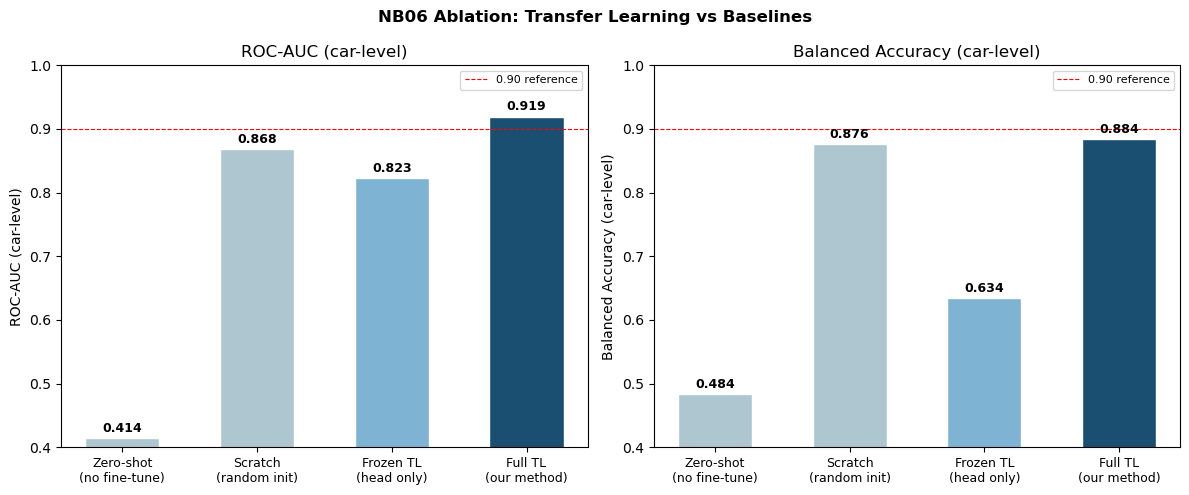

💾 Saved → results/figures/ablation_bar_chart.png


In [17]:
results = {
    "Zero-shot\n(no fine-tune)": (auc_zs, bal_zs),
    "Scratch\n(random init)":    (auc_sc, bal_sc),
    "Frozen TL\n(head only)":    (auc_fr, bal_fr),
    "Full TL\n(our method)":     (auc_ft, bal_ft),
}

print("\n" + "="*60)
print("ABLATION STUDY — Car-level EV Degradation Detection")
print("="*60)
print(f"{'Condition':<30} {'AUC':>8} {'Bal. Acc':>10}")
print("-"*60)
for cond, (auc, bal) in results.items():
    name = cond.replace("\n","  ")
    marker = " ← proposed" if "Full" in cond else ""
    print(f"{name:<30} {auc:>8.4f} {bal:>10.4f}{marker}")
print("="*60)

# ── Bar chart ─────────────────────────────────────────────
labels = list(results.keys())
aucs   = [v[0] for v in results.values()]
bals   = [v[1] for v in results.values()]
colors = ["#aec6cf","#aec6cf","#7fb3d3","#1a4f72"]   # highlight proposed
x = np.arange(len(labels))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, vals, title, ylim in zip(
        axes, [aucs, bals],
        ["ROC-AUC (car-level)", "Balanced Accuracy (car-level)"],
        [(0.4, 1.0), (0.4, 1.0)]):
    bars = ax.bar(x, vals, color=colors, edgecolor="white", width=0.55)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(ylim); ax.set_ylabel(title)
    ax.set_title(title)
    ax.axhline(0.9, color="red", linestyle="--", linewidth=0.8,
               label="0.90 reference")
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9,
                fontweight="bold")

plt.suptitle("NB06 Ablation: Transfer Learning vs Baselines",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/ablation_bar_chart.png", dpi=150)
plt.show()
print(f"💾 Saved → results/figures/ablation_bar_chart.png")


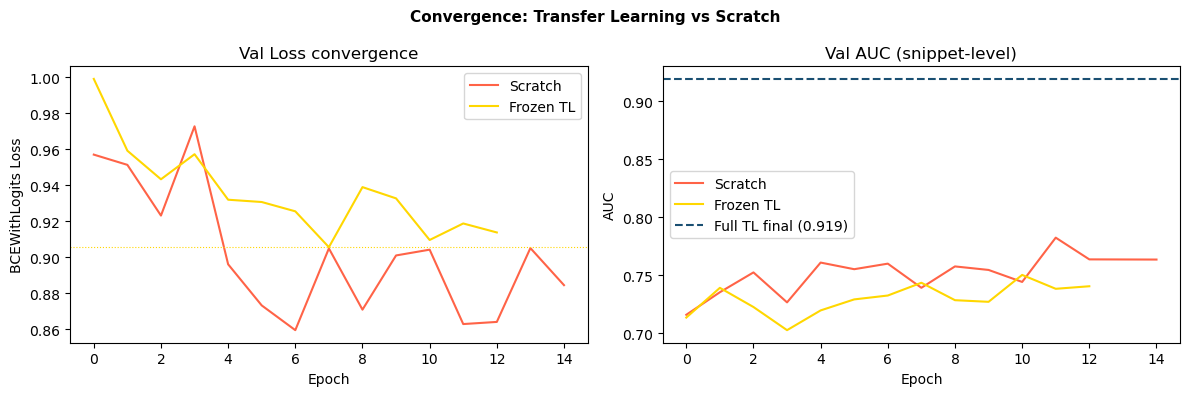

💾 Saved → results/metrics/ablation_results.csv


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_scratch["val"],  label="Scratch",       color="tomato")
axes[0].plot(hist_frozen["val"],   label="Frozen TL",     color="gold")
# Full TL history not saved here — mark its best val
axes[0].axhline(bv_frozen, color="gold",    linestyle=":",  linewidth=0.8)
axes[0].set_title("Val Loss convergence"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCEWithLogits Loss"); axes[0].legend()

axes[1].plot(hist_scratch["auc"], label="Scratch",   color="tomato")
axes[1].plot(hist_frozen["auc"],  label="Frozen TL", color="gold")
axes[1].axhline(auc_ft, color="#1a4f72", linestyle="--",
                label=f"Full TL final ({auc_ft:.3f})", linewidth=1.5)
axes[1].set_title("Val AUC (snippet-level)"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC"); axes[1].legend()

plt.suptitle("Convergence: Transfer Learning vs Scratch",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/ablation_convergence.png", dpi=150)
plt.show()

# Save table to CSV
rows = []
for cond,(auc,bal) in results.items():
    rows.append({"condition": cond.replace("\n"," "), "AUC": auc, "BalAcc": bal})
pd.DataFrame(rows).to_csv(f"{RESULTS_DIR}/ablation_results.csv", index=False)
print(f"💾 Saved → results/metrics/ablation_results.csv")
